# **Simple Linear Regression on Boston House Prices Dataset https://www.kaggle.com/datasets/vikrishnan/boston-house-prices/data**

In [ ]:


import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os


# Download the dataset from Kaggle
path = kagglehub.dataset_download("vikrishnan/boston-house-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'boston-house-prices' dataset.
Path to dataset files: /kaggle/input/boston-house-prices


### **We load the housing dataset from the CSV file using pandas. Since the dataset does not contain column headers, we assign descriptive names to the 13 features and the target variable `MEDV`. The first 13 columns are used as features (`X`), while `MEDV`, representing the house price, is used as the target variable (`y`). Finally, both are converted into NumPy arrays for use with the machine learning model. We also inspect the shape and the first few rows of the dataset to verify that the data was loaded correctly.**

In [ ]:
df = pd.read_csv(
    os.path.join(path, "housing.csv"),
    sep=r"\s+",
    header=None
)

df.columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]

x = df.iloc[:, :13]
y = df.iloc[:, -1]

X = np.array(x) #features
y = np.array(y) #targets

print(df.shape)
print(df.head)
print(X.shape)
print(y.shape)



(506, 14)
<bound method NDFrame.head of         CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273.0   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273.0   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273.0   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273.0   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   

### **To better understand the relationships between the individual features and the target variable, we visualize each feature against the target variable.**

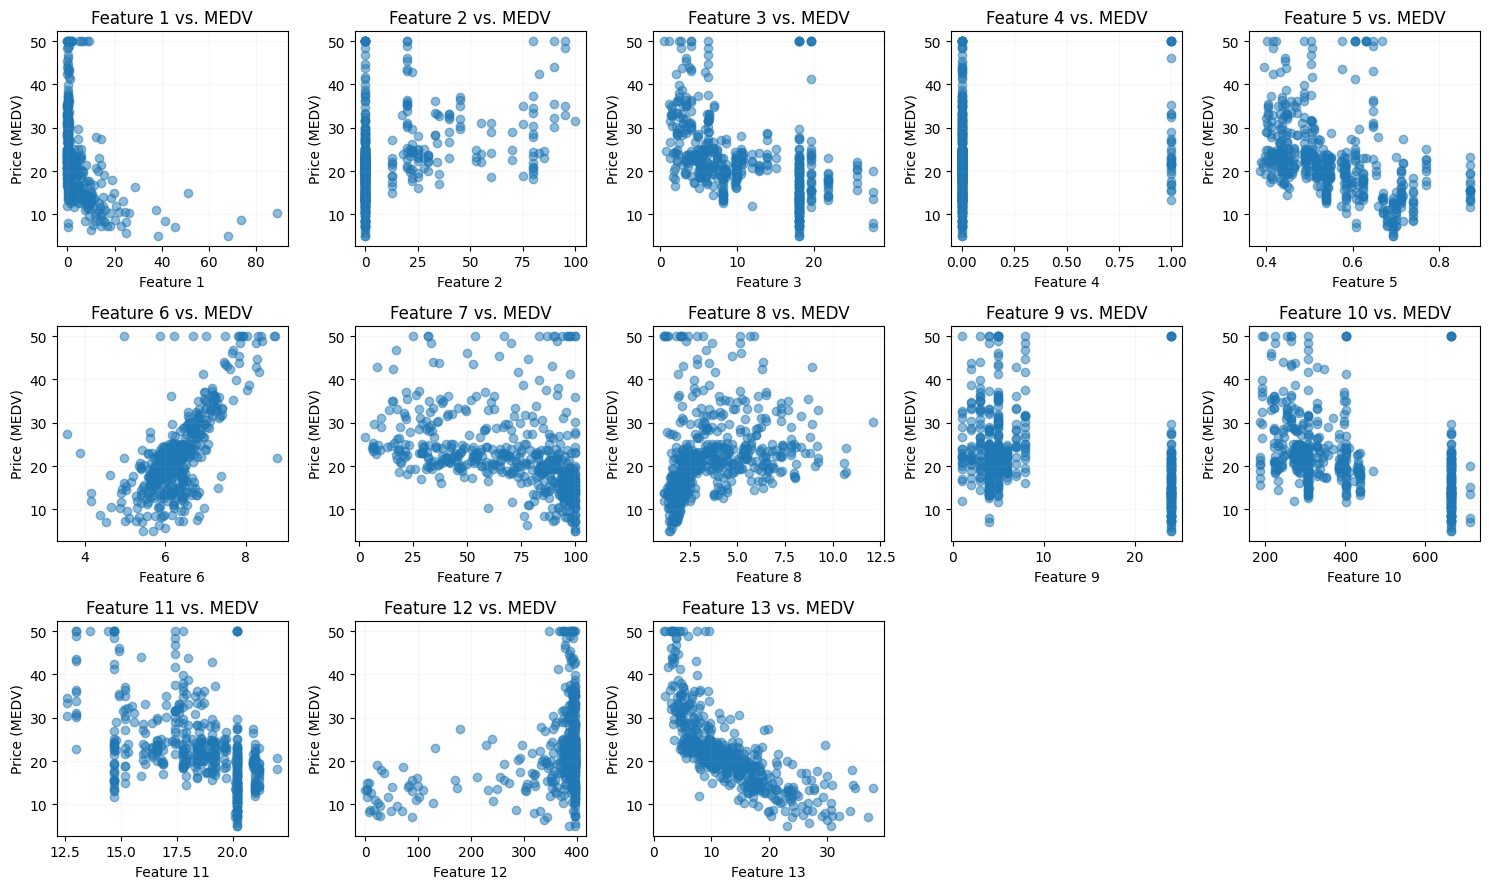

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(13):
    axes[i].scatter(X[:, i], y, alpha=0.5)
    axes[i].set_xlabel(f"Feature {i + 1}")
    axes[i].set_ylabel("Price (MEDV)")
    axes[i].set_title(f"Feature {i + 1} vs. MEDV")
    axes[i].grid(alpha=0.1)

# delete the last 2 empty plots
axes[13].set_visible(False)
axes[14].set_visible(False)

plt.tight_layout()
plt.show()

### **As shown above, the features have significantly different scales. To ensure that all features are on a comparable scale, we apply feature scaling using scikit-learn, transforming the feature values to a range between 0 and 1.**

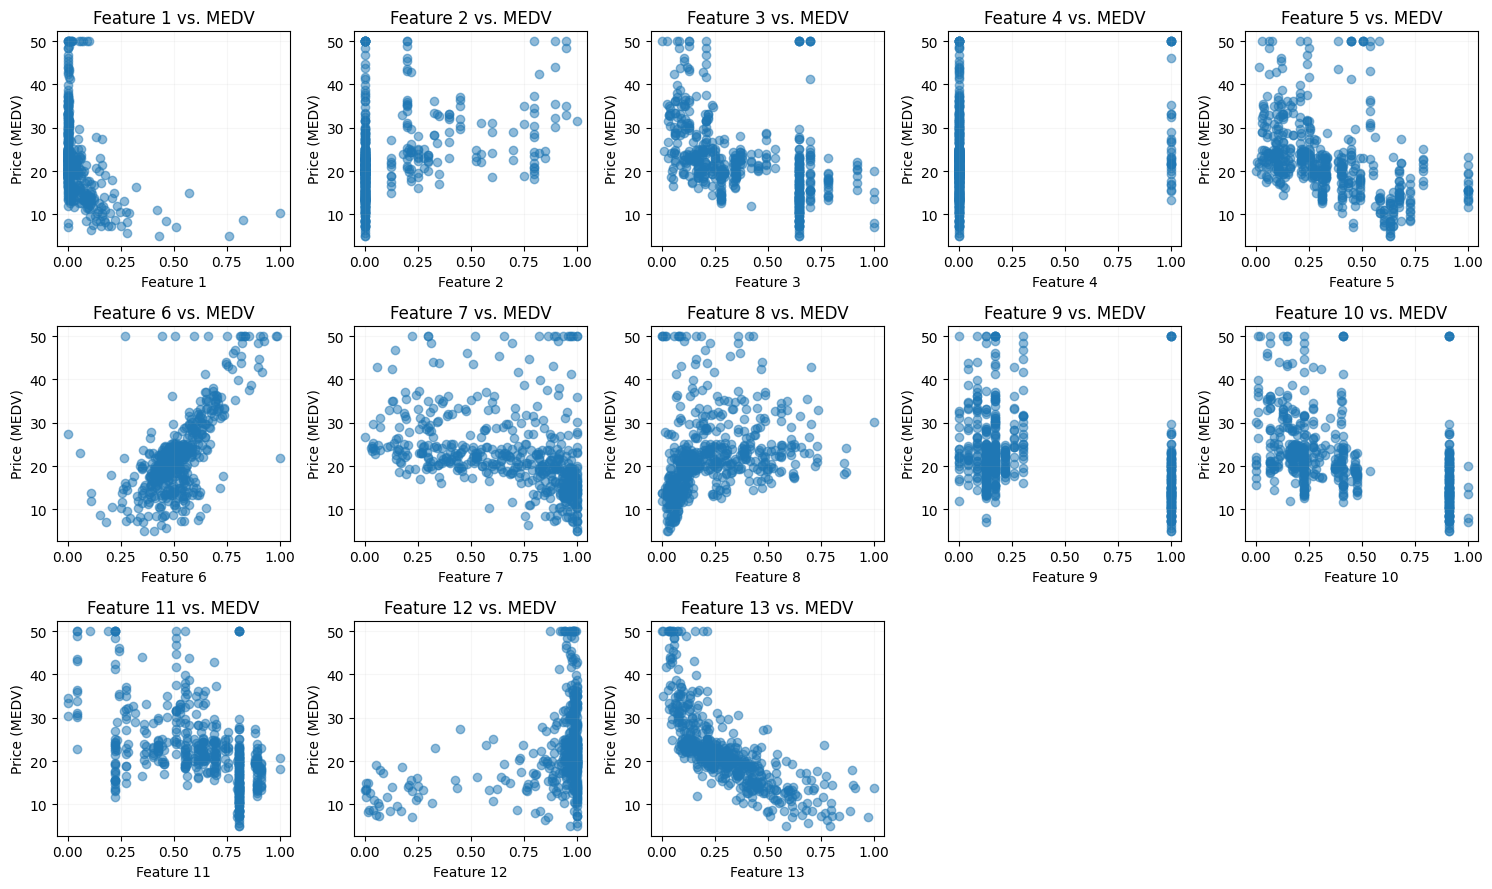

In [ ]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(13):
    axes[i].scatter(X[:, i], y, alpha=0.5)
    axes[i].set_xlabel(f"Feature {i + 1}")
    axes[i].set_ylabel("Price (MEDV)")
    axes[i].set_title(f"Feature {i + 1} vs. MEDV")
    axes[i].grid(alpha=0.1)

# delete the last 2 empty plots
axes[13].set_visible(False)
axes[14].set_visible(False)

plt.tight_layout()
plt.show()

### **We split the dataset into training and test sets, using 70% of the data for training and 30% for testing. We then create a Linear Regression model and train it on the training data. Finally, we use the trained model to predict the target values for the previously unseen test data.**

In [ ]:


X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3) # 30% test data and 70% training data

model = LinearRegression()

model.fit(X_train, Y_train)

y_pred = model.predict(X_test)


### **For each feature, we visualize the training data together with the model predictions on the test data. This provides an overview of how the predicted house prices relate to the individual features.**

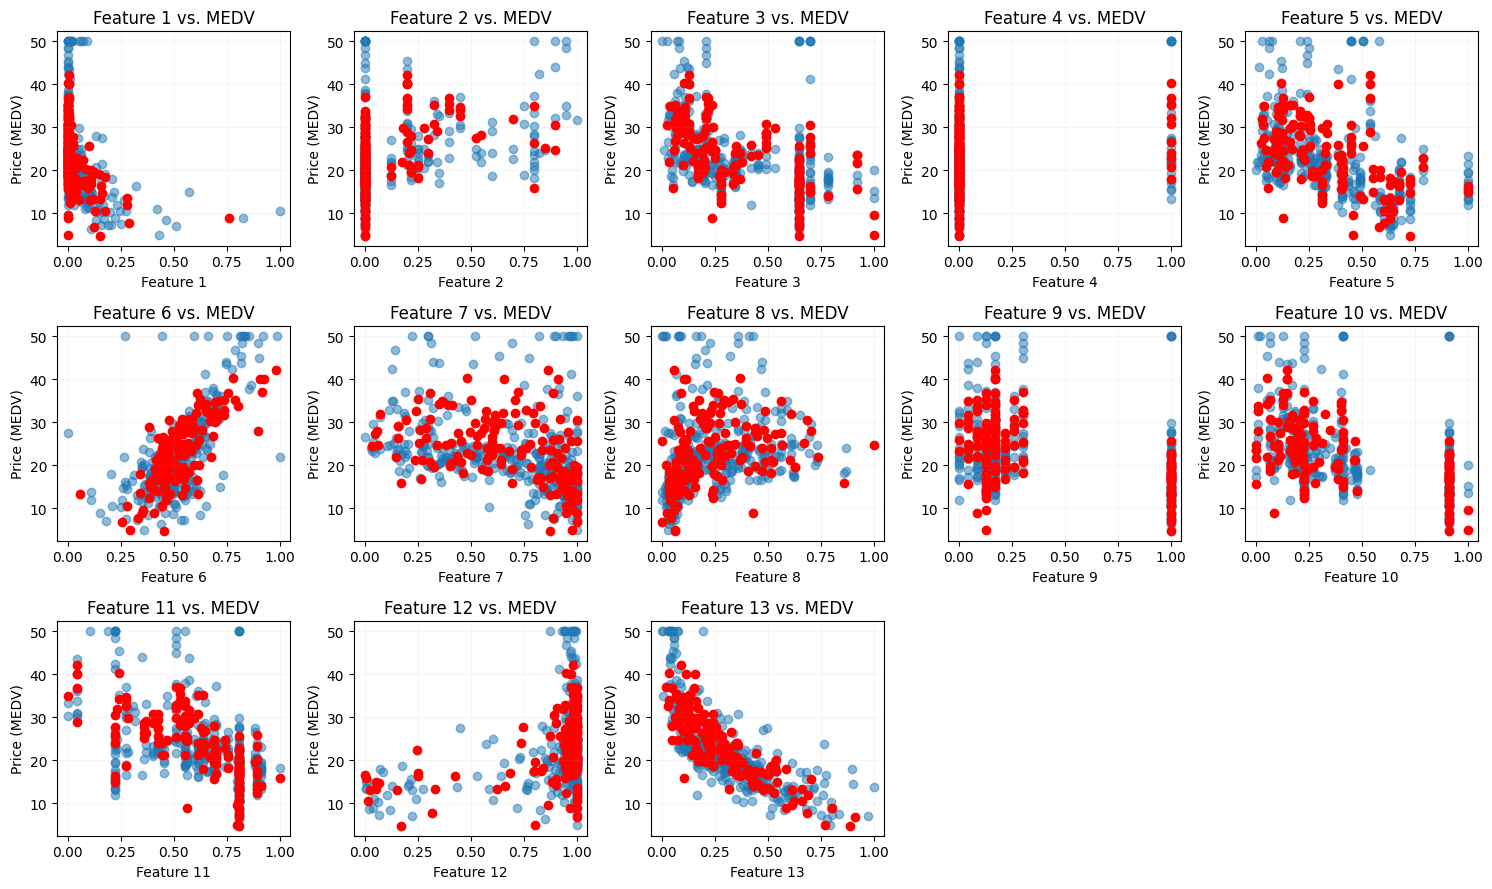

In [ ]:


fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(13):
    axes[i].scatter(X_train[:, i], Y_train, alpha=0.5)
    axes[i].scatter(X_test[:, i], y_pred, color="red")
    axes[i].set_xlabel(f"Feature {i + 1}")
    axes[i].set_ylabel("Price (MEDV)")
    axes[i].set_title(f"Feature {i + 1} vs. MEDV")
    axes[i].grid(alpha=0.1)

# delete the last 2 empty plots
axes[13].set_visible(False)
axes[14].set_visible(False)

plt.tight_layout()
plt.show()

### **To evaluate the performance of the Linear Regression model, we calculate the Root Mean Squared Error (RMSE) and the R² score. The RMSE measures the average prediction error in the same units as the target variable, where lower values indicate better performance. The R² score measures how well the model explains the variance in the target variable, with values closer to 1 indicating a better fit.**

In [ ]:


mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)  # near 0 is good
print("Model Score:", model.score(X_test, Y_test)) # near 1 is good

RMSE: 4.636359629661652
Model Score: 0.7526788463110833


### **To evaluate the predictions visually, we plot the actual house prices against the predicted house prices. The diagonal line represents perfect predictions, where the predicted value is equal to the actual value. The closer the data points are to this line, the more accurate the model's predictions are.**

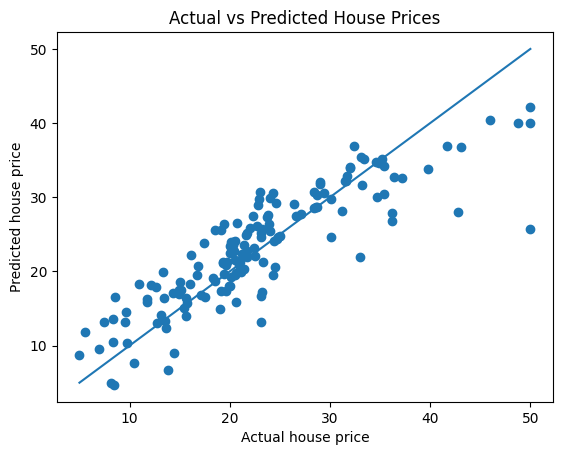

In [ ]:
plt.scatter(Y_test, y_pred)

plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()])

plt.xlabel("Actual house price")
plt.ylabel("Predicted house price")
plt.title("Actual vs Predicted House Prices")
plt.show()

### **To further evaluate the model, we analyze the residuals, which represent the difference between the actual and predicted house prices. The residuals are plotted against the predicted values. A residual of zero indicates a perfect prediction, while positive and negative residuals indicate underprediction and overprediction, respectively. Ideally, the residuals should be randomly distributed around zero without any visible pattern.**

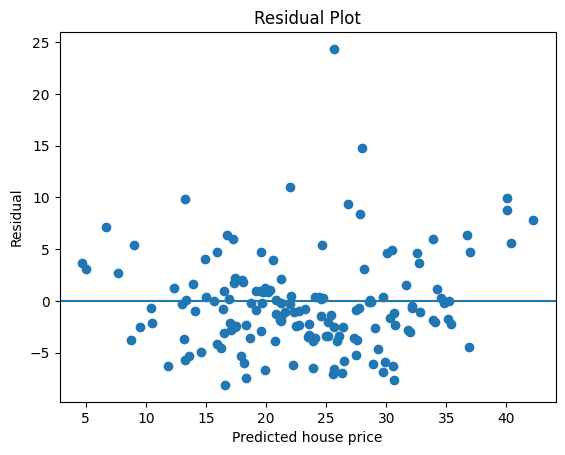

In [ ]:
residuals = Y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted house price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()